<a href="https://colab.research.google.com/github/young0206/computer_vision/blob/main/06.%EC%9E%84%EB%B2%A0%EB%94%94%EB%93%9C/01.delf/DELF_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch


#Installing libraries

In [5]:
# !pip3 install h5py=='2.9.0'
# !pip3 install torch==1.7.0+cu101 torchvision==0.6.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html
!pip3 install progress

#Checking GPU
###GPU necessary for Inference

In [6]:
import torch
torch.cuda.is_available()

True

#Defining Variables

In [7]:
pretrained_model='pretrained_model'
dataset_path='test_data'
prefix_q = 'query/'
prefix_a = 'answer/'

#Importing Libraries

In [9]:
# ============================================
# 최신 scikit-image 호환 처리
# ============================================
from pathlib import Path

matcher_path = Path("helper/matcher.py")

matcher_code = matcher_path.read_text()

# 구버전 plot_matches -> 신버전 plot_matched_features
matcher_code = matcher_code.replace(
    "from skimage.feature import plot_matches",
    "from skimage.feature import plot_matched_features"
)

# 함수 호출 이름도 변경
matcher_code = matcher_code.replace(
    "plot_matches(",
    "plot_matched_features("
)

matcher_path.write_text(matcher_code)

print("matcher.py scikit-image 호환 수정 완료")


# ============================================
# 기존 DELF imports
# ============================================
from PIL import Image
import os
import sys
import time
import random
import logging
import copy
import shutil

from io import BytesIO

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data as data

import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from torch.autograd import Variable

from helper import delf_helper
from helper import Feeder
from helper import matcher

from utils import mkdir_p, Bar, AverageMeter
from train.solver import Solver
from train.config import config

# from train.delf import Delf_V1

print("Import 완료")

matcher.py scikit-image 호환 수정 완료
Import 완료


#Defining Model


In [10]:

# -*- coding: utf-8 -*-

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function


from train.layers import (
    CMul,
    Flatten,
    ConcatTable,
    Identity,
    Reshape,
    SpatialAttention2d,
    WeightedSum2d)


''' helper functions
'''

def __unfreeze_weights__(module_dict, freeze=[]):
    for _, v in enumerate(freeze):
        module = module_dict[v]
        for param in module.parameters():
            param.requires_grad = True

def __freeze_weights__(module_dict, freeze=[]):
    for _, v in enumerate(freeze):
        module = module_dict[v]
        for param in module.parameters():
            param.requires_grad = False

def __print_freeze_status__(model):
    '''print freeze stagus. only for debugging purpose.
    '''
    for i, module in enumerate(model.named_children()):
        for param in module[1].parameters():
            print('{}:{}'.format(module[0], str(param.requires_grad)))

def __load_weights_from__(module_dict, load_dict, modulenames):
    for modulename in modulenames:
        module = module_dict[modulename]
        print('loaded weights from module "{}" ...'.format(modulename))
        module.load_state_dict(load_dict[modulename])

def __deep_copy_module__(module, exclude=[]):
    modules = {}
    for name, m in module.named_children():
        if name not in exclude:
            modules[name] = copy.deepcopy(m)
            print('deep copied weights from layer "{}" ...'.format(name))
    return modules

def __cuda__(model):
    if torch.cuda.is_available():
        model.cuda()
    return model


'''Delf
'''

class Delf_V1(nn.Module):
    def __init__(
        self,
        ncls=None,
        load_from=None,
        arch='resnet50',
        stage='inference',
        target_layer='layer3',
        use_random_gamma_rescale=False):

        super(Delf_V1, self).__init__()

        self.arch = arch
        self.stage = stage
        self.target_layer = target_layer
        self.load_from = load_from
        self.use_random_gamma_rescale = use_random_gamma_rescale

        self.module_list = nn.ModuleList()
        self.module_dict = {}
        self.end_points = {}

        in_c = self.__get_in_c__()
        if self.stage in ['finetune']:
            use_pretrained_base = True
            exclude = ['avgpool', 'fc']

        elif self.stage in ['keypoint']:
            use_pretrained_base = False
            self.use_l2_normalized_feature = True
            if self.target_layer in ['layer3']:
                exclude = ['layer4', 'avgpool', 'fc']
            if self.target_layer in ['layer4']:
                exclude = ['avgpool', 'fc']

        else:
            assert self.stage in ['inference']
            use_pretrained_base = False
            self.use_l2_normalized_feature = True
            if self.target_layer in ['layer3']:
                exclude = ['layer4', 'avgpool', 'fc']
            if self.target_layer in ['layer4']:
                exclude = ['avgpool', 'fc']

        if self.arch in ['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152']:
            print('[{}] loading {} pretrained ImageNet weights ... It may take few seconds...'
                    .format(self.stage, self.arch))
            module = models.__dict__[self.arch](pretrained=use_pretrained_base)
            module_state_dict = __deep_copy_module__(module, exclude=exclude)
            module = None

            # endpoint: base
            submodules = []
            submodules.append(module_state_dict['conv1'])
            submodules.append(module_state_dict['bn1'])
            submodules.append(module_state_dict['relu'])
            submodules.append(module_state_dict['maxpool'])
            submodules.append(module_state_dict['layer1'])
            submodules.append(module_state_dict['layer2'])
            submodules.append(module_state_dict['layer3'])
            self.__register_module__('base', submodules)

            # build structure.
            if self.stage in ['finetune']:
                # endpoint: layer4, pool
                self.__register_module__('layer4', module_state_dict['layer4'])
                self.__register_module__('pool', nn.AvgPool2d(
                    kernel_size=7, stride=1, padding=0,
                    ceil_mode=False, count_include_pad=True))
            elif self.stage in ['keypoint', 'inference']:
                # endpoint: attn, pool
                self.__register_module__('attn', SpatialAttention2d(in_c=in_c, act_fn='relu'))
                self.__register_module__('pool', WeightedSum2d())


            if self.stage not in ['inference']:
                # endpoint: logit
                submodules = []
                submodules.append(nn.Conv2d(in_c, ncls, 1))
                submodules.append(Flatten())
                self.__register_module__('logits', submodules)

            # load weights.
            if self.stage in ['keypoint']:
                load_dict = torch.load(self.load_from)
                __load_weights_from__(self.module_dict, load_dict, modulenames=['base'])
                __freeze_weights__(self.module_dict, freeze=['base'])
                print('load model from "{}"'.format(load_from))
            elif self.stage in ['inference']:
                load_dict = torch.load(self.load_from)
                __load_weights_from__(self.module_dict, load_dict, modulenames=['base','attn','pool'])
                print('load model from "{}"'.format(load_from))


    def __register_module__(self, modulename, module):
        if isinstance(module, list) or isinstance(module, tuple):
            module = nn.Sequential(*module)
        self.module_list.append(module)
        self.module_dict[modulename] = module

    def __get_in_c__(self):
        # adjust input channels according to arch.
        if self.arch in ['resnet18', 'resnet34']:
            in_c = 512
        elif self.arch in ['resnet50', 'resnet101', 'resnet152']:
            if self.stage in ['finetune']:
                in_c = 2048
            elif self.stage in ['keypoint', 'inference']:
                if self.target_layer in ['layer3']:
                    in_c = 1024
                elif self.target_layer in ['layer4']:
                    in_c = 2048
        return in_c

    def __forward_and_save__(self, x, modulename):
        module = self.module_dict[modulename]
        x = module(x)
        self.end_points[modulename] = x
        return x

    def __forward_and_save_feature__(self, x, model, name):
        x = model(x)
        self.end_points[name] = x.data
        return x

    def __gamma_rescale__(self, x, min_scale=0.3535, max_scale=1.0):
        '''max_scale > 1.0 may cause training failure.
        '''
        h, w = x.size(2), x.size(3)
        assert w == h, 'input must be square image.'
        gamma = random.uniform(min_scale, max_scale)
        new_h, new_w = int(h*gamma), int(w*gamma)
        x = F.upsample(x, size=(new_h, new_w), mode='bilinear')
        return x

    def get_endpoints(self):
        return self.end_points

    def get_feature_at(self, modulename):
        return copy.deepcopy(self.end_points[modulename].data.cpu())

    def write_to(self, state):
        if self.stage in ['finetune']:
            state['base'] = self.module_dict['base'].state_dict()
            state['layer4'] = self.module_dict['layer4'].state_dict()
            state['pool'] = self.module_dict['pool'].state_dict()
            state['logits'] = self.module_dict['logits'].state_dict()
        elif self.stage in ['keypoint']:
            state['base'] = self.module_dict['base'].state_dict()
            state['attn'] = self.module_dict['attn'].state_dict()
            state['pool'] = self.module_dict['pool'].state_dict()
            state['logits'] = self.module_dict['logits'].state_dict()
        else:
            assert self.stage in ['inference']
            raise ValueError('inference does not support model saving!')

    def forward_for_serving(self, x):
        '''
        This function directly returns attention score and raw features
        without saving to endpoint dict.
        '''
        x = self.__forward_and_save__(x, 'base')
        if self.target_layer in ['layer4']:
            x = self.__forward_and_save__(x, 'layer4')
        ret_x = x
        if self.use_l2_normalized_feature:
            attn_x = F.normalize(x, p=2, dim=1)
        else:
            attn_x = x
        attn_score = self.__forward_and_save__(x, 'attn')
        ret_s = attn_score
        return ret_x.data.cpu(), ret_s.data.cpu()

    def forward(self, x):
        if self.stage in ['finetune']:
            x = self.__forward_and_save__(x, 'base')
            x = self.__forward_and_save__(x, 'layer4')
            x = self.__forward_and_save__(x, 'pool')
            x = self.__forward_and_save__(x, 'logits')
        elif self.stage in ['keypoint']:
            if self.use_random_gamma_rescale:
                x = self.__gamma_rescale__(x)
            x = self.__forward_and_save__(x, 'base')
            if self.target_layer in ['layer4']:
                x = self.__forward_and_save__(x, 'layer4')
            if self.use_l2_normalized_feature:
                attn_x = F.normalize(x, p=2, dim=1)
            else:
                attn_x = x
            attn_score = self.__forward_and_save__(x, 'attn')
            x = self.__forward_and_save__([attn_x, attn_score], 'pool')
            x = self.__forward_and_save__(x, 'logits')

        elif self.stage in ['inference']:
            x = self.__forward_and_save__(x, 'base')
            if self.target_layer in ['layer4']:
                x = self.__forward_and_save__(x, 'layer4')
            if self.use_l2_normalized_feature:
                attn_x = F.normalize(x, p=2, dim=1)
            else:
                attn_x = x
            attn_score = self.__forward_and_save__(x, 'attn')
            x = self.__forward_and_save__([attn_x, attn_score], 'pool')

        else:
            raise ValueError('unsupported stage parameter: {}'.format(self.stage))
        return x

if __name__=="__main__":
    pass;











#Downloading Dataset
###Google Landmarks is a huge Dataset , 106GB Hence only downloading a part of it for training


In [11]:

if os.path.exists(dataset_path)  is False:
  !mkdir train_data
  !mkdir test_data
  %cd test_data
  !bash ../download-dataset.sh  test 0

  # %cd train_data
  # !bash ../download-dataset.sh train 499
  %cd ..
else:
  print('Dataset already Downloaded')

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data
images_000.tar extracted!
/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch


#Downloading Pretrained Model

In [12]:
import os
if os.path.exists(pretrained_model) is False:
  print("Downloading pretrained weights")
  os.makedirs(pretrained_model, exist_ok=True)
  %cd pretrained_model

  !gdown https://drive.google.com/u/0/uc?id=1dbdaDyVeIb53iGh4Uk5kA4in9-uURoLM&export=download
  !tar -xvf /content/drive/MyDrive/DeLF-pytorch/pretrained_model/pretrained_model.tar
  %cd ..

else:
  print('Pre_trained Model Already Downloaded')

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/pretrained_model
Downloading...
From (original): https://drive.google.com/u/0/uc?id=1dbdaDyVeIb53iGh4Uk5kA4in9-uURoLM
From (redirected): https://drive.google.com/uc?id=1dbdaDyVeIb53iGh4Uk5kA4in9-uURoLM&confirm=t&uuid=fe79cea8-e780-4e02-8a56-3da4facea199
To: /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/pretrained_model/pretrained_model.tar
100% 181M/181M [00:03<00:00, 55.6MB/s]
tar: /content/drive/MyDrive/DeLF-pytorch/pretrained_model/pretrained_model.tar: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch


In [13]:
%cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/pretrained_model

!tar -xvf pretrained_model.tar

%cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/pretrained_model
pretrained_model/
pretrained_model/ldmk/
pretrained_model/ldmk/model/
pretrained_model/ldmk/model/finetune/
pretrained_model/ldmk/model/finetune/ckpt/
pretrained_model/ldmk/model/finetune/ckpt/bestshot.pth.tar
pretrained_model/ldmk/model/finetune/log/
pretrained_model/ldmk/model/finetune/log/train.log
pretrained_model/ldmk/model/finetune/log/val.log
pretrained_model/ldmk/model/keypoint/
pretrained_model/ldmk/model/keypoint/ckpt/
pretrained_model/ldmk/model/keypoint/ckpt/bestshot.pth.tar
pretrained_model/ldmk/model/keypoint/ckpt/fix.pth.tar
pretrained_model/ldmk/model/keypoint/log/
pretrained_model/ldmk/model/keypoint/log/train.log
pretrained_model/ldmk/model/keypoint/log/val.log
pretrained_model/ldmk/pca/
pretrained_model/ldmk/pca/pca.h5
/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch


#Training Script

In [15]:
project_path = "/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch"
dataset_path = project_path + "/test_data"

config.train_path_for_pretraining = dataset_path
config.val_path_for_pretraining = dataset_path
config.train_path_for_finetuning = dataset_path
config.val_path_for_finetuning = dataset_path

print("train_path_for_pretraining :", config.train_path_for_pretraining)
print("val_path_for_pretraining   :", config.val_path_for_pretraining)
print("train_path_for_finetuning  :", config.train_path_for_finetuning)
print("val_path_for_finetuning    :", config.val_path_for_finetuning)

print("\n데이터셋 존재 여부:", os.path.exists(dataset_path))

train_path_for_pretraining : /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data
val_path_for_pretraining   : /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data
train_path_for_finetuning  : /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data
val_path_for_finetuning    : /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data

데이터셋 존재 여부: True


In [16]:



def main():
    # print config.
    state = {k: v for k, v in config._get_kwargs()}
    print(state)

    # if use cuda.
    os.environ['CUDA_VISIBLE_DEVICES'] = config.gpu_id
    use_cuda = torch.cuda.is_available()

    # Random seed
    if config.manualSeed is None:
        config.manualSeed = random.randint(1, 10000)
    random.seed(config.manualSeed)
    torch.manual_seed(config.manualSeed)
    if use_cuda:
        torch.cuda.manual_seed_all(config.manualSeed)
        torch.backends.cudnn.benchmark = True           # speed up training.

    # data loader
    from train.dataloader import get_loader
    if config.stage in ['finetune']:
        sample_size = config.finetune_sample_size
        crop_size = config.finetune_crop_size
    elif config.stage in ['keypoint']:
        sample_size = config.keypoint_sample_size
        crop_size = config.keypoint_crop_size

    # dataloader for pretrain
    train_loader_pt, val_loader_pt = get_loader(
        train_path = config.train_path_for_pretraining,
        val_path = config.val_path_for_pretraining,
        stage = config.stage,
        train_batch_size = config.train_batch_size,
        val_batch_size = config.val_batch_size,
        sample_size = sample_size,
        crop_size = crop_size,
        workers = config.workers)
    # dataloader for finetune
    train_loader_ft, val_loader_ft = get_loader(
        train_path = config.train_path_for_finetuning,
        val_path = config.val_path_for_finetuning,
        stage = config.stage,
        train_batch_size = config.train_batch_size,
        val_batch_size = config.val_batch_size,
        sample_size = sample_size,
        crop_size = crop_size,
        workers = config.workers)


    # load model
    # from delf import Delf_V1
    model = Delf_V1(
        ncls = config.ncls,
        load_from = config.load_from,
        arch = config.arch,
        stage = config.stage,
        target_layer = config.target_layer,
        use_random_gamma_rescale = config.use_random_gamma_rescale)

    # solver

    solver = Solver(config=config, model=model)
    if config.stage in ['finetune']:
        epochs = config.finetune_epoch
    elif config.stage in ['keypoint']:
        epochs = config.keypoint_epoch

    # train/test for N-epochs. (50%: pretain with datasetA, 50%: finetune with datasetB)
    for epoch in range(epochs):
        if epoch < int(epochs * 0.5):
            print('[{:.1f}] load pretrain dataset: {}'.format(
                float(epoch) / epochs,
                config.train_path_for_pretraining))
            train_loader = train_loader_pt
            val_loader = val_loader_pt
        else:
            print('[{:.1f}] load finetune dataset: {}'.format(
                float(epoch) / epochs,
                config.train_path_for_finetuning))
            train_loader = train_loader_ft
            val_loader = val_loader_ft

        solver.train('train', epoch, train_loader, val_loader)
        solver.train('val', epoch, train_loader, val_loader)

    print('Congrats! You just finished DeLF training.')


if __name__ == '__main__':
    main()


{'gpu_id': '4', 'manualSeed': 1790745944, 'expr': 'devel', 'load_from': 'dummy', 'stage': 'finetune', 'train_path_for_pretraining': '/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data', 'val_path_for_pretraining': '/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data', 'train_path_for_finetuning': '/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data', 'val_path_for_finetuning': '/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/test_data', 'workers': 20, 'finetune_sample_size': 256, 'finetune_crop_size': 224, 'keypoint_sample_size': 900, 'keypoint_crop_size': 720, 'target_layer': 'layer3', 'use_random_gamma_rescale': True, 'finetune_epoch': 30, 'keypoint_epoch': 30, 'lr': 0.008, 'lr_gamma': 0.5, 'lr_stepsize': 10, 'weight_decay': 0.0001, 'optim': 'sgd', 'train_batch_size': 8, 'val_batch_size': 8, 'ncls': 586, 'lr_decay': 0.5, 'arch': 'resnet50'}


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[finetune] loading resnet50 pretrained ImageNet weights ... It may take few seconds...


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/train/solver.py:219: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.lr_scheduler.step()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/


[train][epoch:1][iter:(1/735)][lr:0.008] loss: 6.3411 | top1: 0.0000 | top3: 0.0000 | top5: 0.0000 | eta: (data:2.086s),(batch:7.055s),(total:0:00:07)

[train][epoch:1][iter:(2/735)][lr:0.008] loss: 4.6006 | top1: 50.0000 | top3: 50.0000 | top5: 50.0000 | eta: (data:0.003s),(batch:0.051s),(total:0:00:07)

[train][epoch:1][iter:(3/735)][lr:0.008] loss: 3.2302 | top1: 66.6667 | top3: 66.6667 | top5: 66.6667 | eta: (data:0.032s),(batch:0.085s),(total:0:00:07)

[train][epoch:1][iter:(4/735)][lr:0.008] loss: 2.4902 | top1: 75.0000 | top3: 75.0000 | top5: 75.0000 | eta: (data:0.032s),(batch:0.067s),(total:0:00:07)

[train][epoch:1][iter:(5/735)][lr:0.008] loss: 2.0099 | top1: 80.0000 | top3: 80.0000 | top5: 80.0000 | eta: (data:0.057s),(batch:0.095s),(total:0:00:07)

[train][epoch:1][iter:(6/735)][lr:0.008] loss: 1.6877 | top1: 83.3333 | top3: 83.3333 | top5: 83.3333 | eta: (data:0.044s),(batch:0.092s),(total:0:00:07)

[train][epoch:1][iter:(7/735)][lr:0.008] loss: 1.4565 | top1: 85.7143 | 

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/train/solver.py:33: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  return Variable(x, volatile=volatile)


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[train][epoch:4][iter:(38/735)][lr:0.008] loss: 0.0001 | top1: 100.0000 | top3: 100.0000 | top5: 100.0000 | eta: (data:0.016s),(batch:0.201s),(total:0:00:09)

[train][epoch:4][iter:(39/735)][lr:0.008] loss: 0.0001 | top1: 100.0000 | top3: 100.0000 | top5: 100.0000 | eta: (data:0.003s),(batch:0.125s),(total:0:00:09)

[train][epoch:4][iter:(40/735)][lr:0.008] loss: 0.0001 | top1: 100.0000 | top3: 100.0000 | top5: 100.0000 | eta: (data:0.006s),(batch:0.160s),(total:0:00:09)

[train][epoch:4][iter:(41/735)][lr:0.008] loss: 0.0001 | top1: 100.0000 | top3: 100.0000 | top5: 100.0000 | eta: (data:0.037s),(batch:0.163s),(total:0:00:09)

[train][epoch:4][iter:(42/735)][lr:0.008] loss: 0.0001 | top1: 100.0000 | top3: 100.0000 | top5: 100.0000 | eta: (data:0.004s),(batch:0.105s),(total:0:00:09)

[train][epoch:4][iter:(43/735)][lr:0.008] loss: 0.0001 | top1: 100.0000 | top3: 100.0000 | top5: 100.0000 | eta: (data:0.020s),(batch:0.127s),(total:0:00:09)

[train][ep

KeyboardInterrupt: 

#Defining Functions for Inference

In [17]:
def resize_image(image, target_size=800):
    def calc_by_ratio(a, b):
        return int(a * target_size / float(b))

    size = image.size
    if size[0] < size[1]:
        w = calc_by_ratio(size[0], size[1])
        h = target_size
    else:
        w = target_size
        h = calc_by_ratio(size[1], size[0])

    image = image.resize((w, h), Image.BILINEAR)
    return image


def get_and_cache_image(image_path, basewidth=None):
    image = Image.open(image_path)
    if basewidth is not None:
        image = resize_image(image, basewidth)
    imgByteArr = BytesIO()
    image.save(imgByteArr, format='PNG')
    imgByteArr = imgByteArr.getvalue()
    return image, imgByteArr


def get_result(feeder, query):
    pil_image = []
    byte_image = []
    for _, v in enumerate(query):
        pil, byte = get_and_cache_image(v)
        pil_image.append(pil)
        byte_image.append(byte)

    # feed and get output.
    outputs = feeder.feed_to_compare(query, pil_image)
    print('# of extracted feature (qeuery):', len(outputs[0]['descriptor_np_list']))
    print('# of extracted feature (db):', len(outputs[0]['descriptor_np_list']))

    att1 = matcher.get_attention_image_byte(outputs[0]['attention_np_list'])
    att2 = matcher.get_attention_image_byte(outputs[1]['attention_np_list'])

    side_by_side_comp_img_byte, score = matcher.get_ransac_image_byte(
        byte_image[0],
        outputs[0]['location_np_list'],
        outputs[0]['descriptor_np_list'],
        byte_image[1],
        outputs[1]['location_np_list'],
        outputs[1]['descriptor_np_list'])
    print('matching inliner num:', score)
    return side_by_side_comp_img_byte, att1, att2

#Inference Script

load DeLF pytorch model...
{'stage': 'inference', 'expr': 'dummy', 'ncls': 'dummy', 'use_random_gamma_rescale': False, 'arch': 'resnet50', 'load_from': 'pretrained_model/pretrained_model/ldmk/model/keypoint/ckpt/fix.pth.tar', 'target_layer': 'layer3'}
[inference] loading resnet50 pretrained ImageNet weights ... It may take few seconds...
deep copied weights from layer "conv1" ...
deep copied weights from layer "bn1" ...
deep copied weights from layer "relu" ...
deep copied weights from layer "maxpool" ...
deep copied weights from layer "layer1" ...
deep copied weights from layer "layer2" ...
deep copied weights from layer "layer3" ...
loaded weights from module "base" ...
loaded weights from module "attn" ...
loaded weights from module "pool" ...
load model from "pretrained_model/pretrained_model/ldmk/model/keypoint/ckpt/fix.pth.tar"
PCA disabled - skip loading PCA parameters


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/helper/delf_helper.py:395: UserWarning: An output with one or more elements was resized since it had shape [626], which does not match the required output shape [625]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  torch.index_select(x1, 0, idx, out=xx1)
/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/helper/delf_helper.py:396: UserWarning: An output with one or more elements was resized since it had shape [626], which does not match the required output shape [625]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tenso

# of extracted feature (qeuery): 1000
# of extracted feature (db): 1000
attn_score shape: (1, 1, 43, 64)
attn_score shape: (1, 1, 41, 30)
matching inliner num: 158
# of extracted feature (qeuery): 1000
# of extracted feature (db): 1000
attn_score shape: (1, 1, 29, 50)
attn_score shape: (1, 1, 29, 50)
matching inliner num: 1000


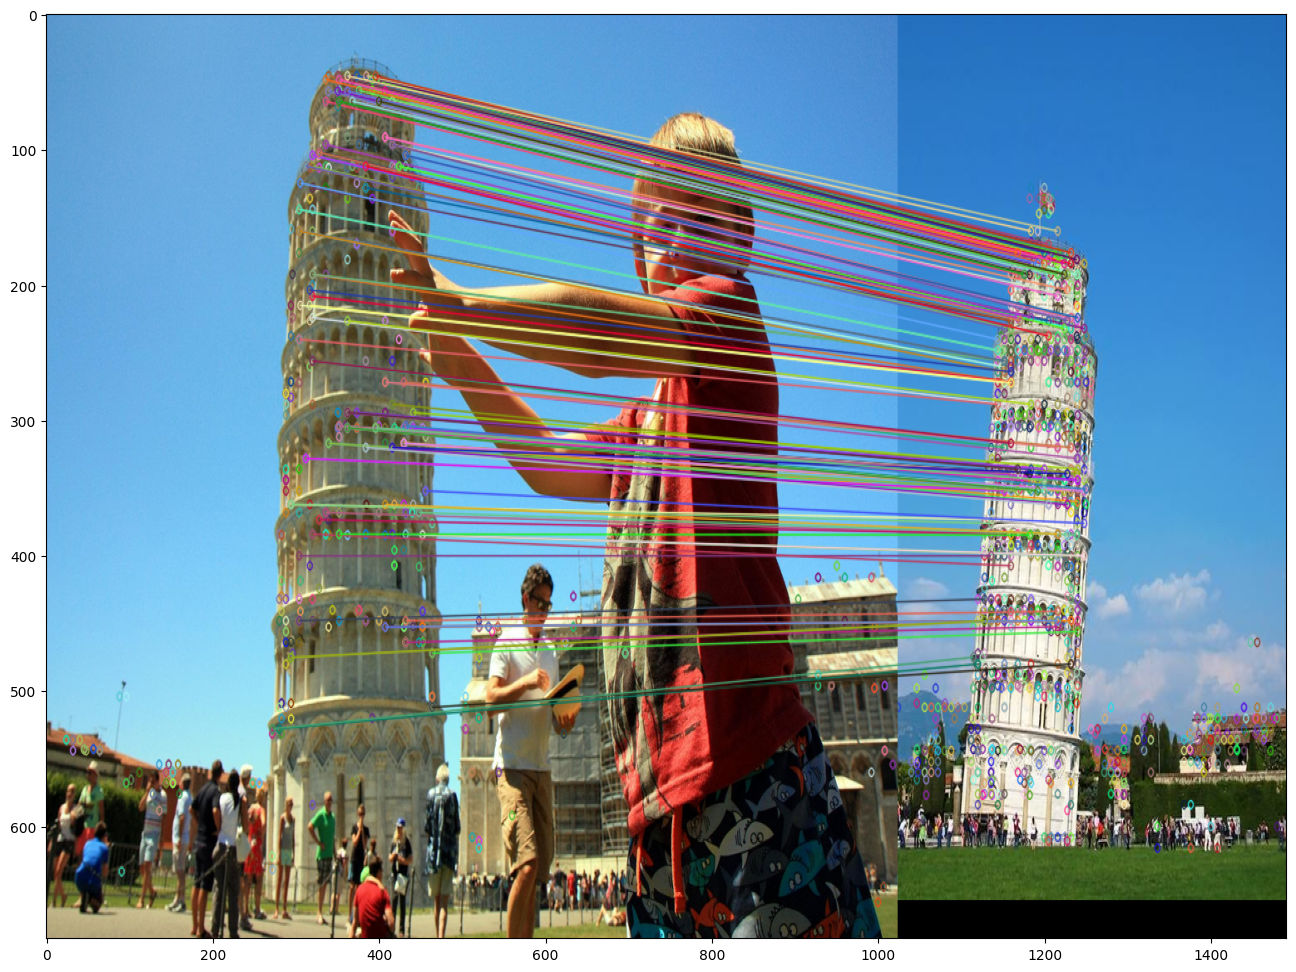

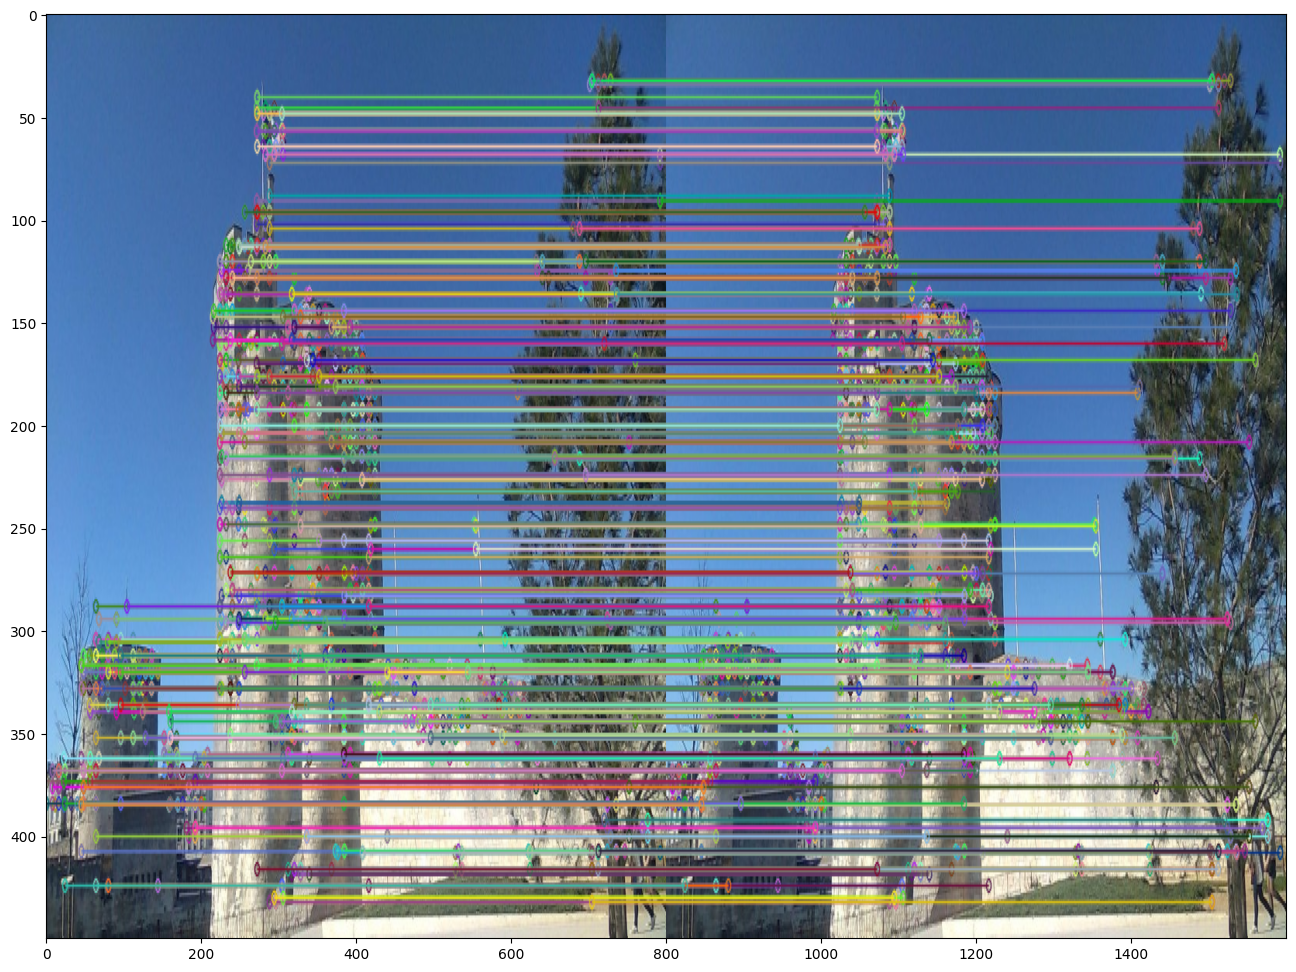

In [25]:


feeder_config = {
    'GPU_ID': 0,
    'IOU_THRES': 0.98,
    'ATTN_THRES': 0.37,
    'TARGET_LAYER': 'layer3',
    'TOP_K': 1000,
    'WORKERS':1,
    'PCA_PARAMETERS_PATH':'pretrained_model/pretrained_model/ldmk/pca/pca.h5',
    'PCA_DIMS':40,
    'USE_PCA': False,
    'SCALE_LIST': [0.25, 0.3535, 0.5, 0.7071, 1.0, 1.4147, 2.0],
    'LOAD_FROM': 'pretrained_model/pretrained_model/ldmk/model/keypoint/ckpt/fix.pth.tar',
    'ARCH': 'resnet50',
    'EXPR': 'dummy',
    'TARGET_LAYER': 'layer3',
}
myfeeder = Feeder(feeder_config)






for i in range(len(os.listdir('query'))):
  query=[prefix_q+f'{i}.jpg',prefix_a+f'{i}.jpg']
  result_image_byte, att1, att2 = get_result(myfeeder, query)
  plt.figure(figsize=(16,12))
  result_image = Image.open(BytesIO(result_image_byte))
  imshow(np.asarray(result_image), aspect='auto')
  # plt.figure(figsize=(4,3))
  # att1_image = Image.open(BytesIO(att1))
  # imshow(np.asarray(att1_image), aspect='auto')
  # plt.figure(figsize=(4,3))
  # att2_image = Image.open(BytesIO(att2))
  # imshow(np.asarray(att2_image), aspect='auto')




In [24]:
import importlib
import helper.feeder

importlib.reload(helper.feeder)

Feeder = helper.feeder.Feeder

print("feeder.py 다시 로드 완료")

feeder.py 다시 로드 완료
